In [2]:
import pandas as pd
from pymc_toolkit.pymc_model import PymcModel

data = pd.read_csv('data/Poseidon.csv')

target_name = 'total_revenue'

First, we are going to find the most correlated variables versus target variable ´total_revenue´. We left the last time point to drop and incomplete week

In [3]:
pd.set_option('display.max_rows', None)

pd.DataFrame(data.iloc[:-1,1:].corr()[target_name]).sort_values(target_name)

,total_revenue
google_ads_shopping_clicks,-0.163843
google_ads_shopping_costs,-0.148000
google_ads_shopping_impressions,-0.139068
google_ads_display_clicks,0.074576
google_ads_display_impressions,0.083908
google_ads_display_costs,0.108013
google_ads_video_impressions,0.113068
google_ads_discovery_costs,0.178211
google_ads_discovery_clicks,0.191100
google_ads_video_costs,0.209197


As we can see, we have the total_revenue, also shopify and amazon revenue, so we will thest if the total is the some of both variables.

<Axes: >

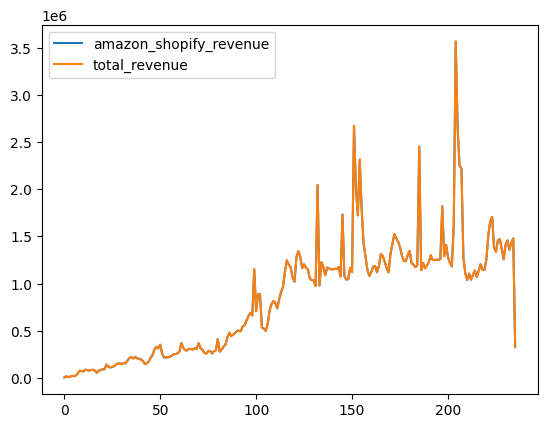

In [4]:
data['amazon_shopify_revenue'] = data['amazon_revenue'] + data['shopify_revenue']
data[['amazon_shopify_revenue', target_name]].plot()

Indeed, so we will repeat the test of correlation with both variables and we will considerate the most correlated variables.

In [5]:
pd.DataFrame(data.iloc[:-1,1:].corr()['amazon_revenue']).sort_values('amazon_revenue')

,amazon_revenue
google_ads_shopping_clicks,-0.133439
google_ads_shopping_costs,-0.122540
google_ads_shopping_impressions,-0.106595
google_ads_display_clicks,0.059849
google_ads_display_impressions,0.066814
google_ads_display_costs,0.088287
google_ads_video_impressions,0.095217
google_ads_discovery_costs,0.153690
google_ads_discovery_clicks,0.175268
google_ads_video_costs,0.183560


We just are going to considerate the most correlated of "costs" type variable.

In [6]:
channel_amazon = ['amazon_ads_spend','google_ads_search_brand_costs', 'google_ads_others_costs']

Repeat con shopify.

In [7]:
pd.DataFrame(data.iloc[:-1,1:].corr()['shopify_revenue']).sort_values('shopify_revenue')

,shopify_revenue
google_ads_shopping_clicks,-0.194413
google_ads_shopping_impressions,-0.175395
google_ads_shopping_costs,-0.172494
google_ads_display_clicks,0.089873
google_ads_display_impressions,0.101935
google_ads_display_costs,0.127672
google_ads_video_impressions,0.129291
google_ads_discovery_clicks,0.196190
google_ads_discovery_costs,0.198150
dsp_spend_others_amazondspspend,0.217393


The shopify variables.

In [8]:
channel_shopify = ['fb_bof_spend', 'google_ads_search_brand_costs', 'fb_tof_spend', 'google_ads_others_costs']

Now we have the channels variables, and we will considerate the same control variables for benchmark model.

In [9]:
control_names = ['discounts', 'emails_us_total_emails_sent', 'influencers_us_total_reach']
channel_names = list(set(channel_amazon + channel_shopify))
data = data[['total_revenue', 'date_week'] + control_names + channel_names].copy()


df_events = pd.DataFrame(
    {
        "name": ["CyberWeek", "ProductLaunch"],
        "start_date": ["2024-11-25", "2024-03-10"],
        "end_date":   ["2024-12-02", "2024-03-12"],
    }
)

df_events["start_date"] = pd.to_datetime(df_events["start_date"])
df_events["end_date"] = pd.to_datetime(df_events["end_date"])

model = PymcModel(client_data=data,
             target_name=target_name,
             date_column='date_week',
             channel_names=channel_names,
             control_names=control_names,
             df_events=df_events,          # <-- activa eventos
             events_basis="gaussian",
             events_sigma_days=14.0,       # para weekly suele ir bien 7–21
             events_prefix="event",
             lag_max=1,
             scale_data=True,
             saturation='michaelis_menten',
             time_varying_media=True)

INFO:pymc_toolkit.pymc_model:Injected 2 event feature(s) into controls: ['event_CyberWeek', 'event_ProductLaunch']
INFO:pymc_toolkit.pymc_model:Creating the client's data configuration.
INFO:pymc_toolkit.client_config:Validate Client's data
INFO:pymc_toolkit.client_config:Validate Media channels
INFO:pymc_toolkit.client_config:available channels:['google_ads_others_costs', 'fb_tof_spend', 'fb_bof_spend', 'google_ads_search_brand_costs', 'amazon_ads_spend']
INFO:pymc_toolkit.client_config:Validate control channels
INFO:pymc_toolkit.client_config:available controls:['discounts', 'emails_us_total_emails_sent', 'influencers_us_total_reach', 'event_CyberWeek', 'event_ProductLaunch']
INFO:pymc_toolkit.client_config:Identify unused columns from client's data
INFO:pymc_toolkit.client_config:Target variable scaled using MaxAbsScaler.
INFO:pymc_toolkit.client_config:Channel variables scaled using MaxAbsScaler.
INFO:pymc_toolkit.client_config:Control variables scaled using MaxAbsScaler.
INFO:pymc

In [10]:
pfleet = model.production_fleet(n_test=12, chains=4, draws=1000,tune=500,cores=4)
pfleet.summary()

INFO:pymc_toolkit.pymc_model:12 steps out of sample production fleet.
INFO:pymc_toolkit.client_config:Returning channels in scaled form.
INFO:pymc_toolkit.client_config:Returning controls in scaled form.
INFO:pymc_toolkit.client_config:Covariates DataFrame constructed with shape (236, 11).
INFO:pymc_toolkit.client_config:Returning target in original scale.
INFO:pymc_toolkit.utils:Total samples: 236
INFO:pymc_toolkit.utils:Single split: train size = 224, test size = 12
INFO:pymc_toolkit.pymc_model:Sampling MMM using 4 chains, 1000 draws, and 500 tuning steps.
INFO:/opt/miniconda3/envs/cassandra12/lib/python3.12/site-packages/pytensor/link/c/lazylinker_c.py:Compiling new CVM
INFO:/opt/miniconda3/envs/cassandra12/lib/python3.12/site-packages/pytensor/link/c/lazylinker_c.py:New version 0.31
Initializing NUTS using adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 

/opt/miniconda3/envs/cassandra12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 25 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 25 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


/opt/miniconda3/envs/cassandra12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

INFO:pymc_toolkit.pymc_model:Sampling completed.
INFO:pymc_toolkit.pymc_model:Predict 12-steps out of sample.
Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]


/opt/miniconda3/envs/cassandra12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

INFO:pymc_toolkit.fleet_result:Initializing FleetResult...
INFO:pymc_toolkit.fleet_result:Computing in-sample predictions (y_fit)...
Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]
INFO:pymc_toolkit.fleet_result:In-sample predictions computed.
INFO:pymc_toolkit.fleet_result:Test set detected — in-sample fit computed.
INFO:pymc_toolkit.fleet_result:Generating diagnostics summary...
INFO:pymc_toolkit.fleet_result:Retrieving MCMC diagnostics...
INFO:pymc_toolkit.fleet_result:MCMC diagnostics retrieved.
INFO:pymc_toolkit.fleet_result:Calculating train metrics...
INFO:pymc_toolkit.fleet_result:Train metrics calculated.
INFO:pymc_toolkit.fleet_result:Calculating test metrics...
INFO:pymc_toolkit.fleet_result:Test metrics calculated.
INFO:pymc_toolkit.fleet_result:Diagnostics summary generated.


{'divergences': 0,
 'max_tree_depth': 8,
 'train': {'mape': 0.4902666415707566,
  'nrmse': 0.03720707973752727,
  'r_squared': 0.9542614134107323,
  'crps_error': 0.05727307474427343},
 'test': {'mape': 0.11386176820352145,
  'nrmse': 0.14028492949054186,
  'r_squared': 0.8361629553290298,
  'crps_error': 0.04521723231283918}}

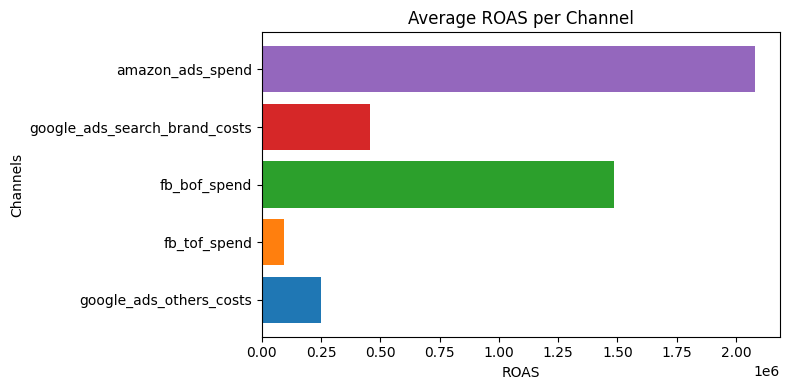

Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]
INFO:pymc_toolkit.fleet_result:Calculating train metrics...
INFO:pymc_toolkit.fleet_result:Train metrics calculated.
INFO:pymc_toolkit.fleet_result:Retrieving MCMC diagnostics...
INFO:pymc_toolkit.fleet_result:MCMC diagnostics retrieved.
INFO:pymc_toolkit.fleet_result:Calculating test metrics...
INFO:pymc_toolkit.fleet_result:Test metrics calculated.


'/Users/grios/cassandra/toy_prod_fleet_events.html'

In [12]:
pfleet.generate_report(output_html="toy_prod_fleet_events.html")

Why Incorporate Events in MMM

Incorporating events into the Marketing Mix Model improves attribution by explicitly modeling exogenous demand shocks (e.g., promotions, launches, seasonal spikes) that are not driven by media spend.

Without events, the model tends to misattribute these effects to marketing channels or the intercept, leading to biased channel contributions and distorted ROI estimates. Event features help isolate non-media effects, resulting in more stable posteriors, cleaner media coefficients, and more credible incremental impact estimates.

Overall, adding events enhances model interpretability, causal validity, and forecasting reliability, especially in periods with strong non-marketing drivers—provided the number of events is kept small and well-justified.